# Logistic Regression

2025-10-03

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Generate synthetic binary classification data
np.random.seed(42)
n_samples = 1000
n_features = 2
X = np.random.randn(n_samples, n_features)

# True coefficients
b0, b1, b2 = 0.5, 1.0, -1.5
log_odds = b0 + b1 * X[:, 0] + b2 * X[:, 1]
prob = 1 / (1 + np.exp(-log_odds))
y = np.random.binomial(1, prob)
data = pd.DataFrame(X, columns=['X1', 'X2'])
data['y'] = y

# Fit logistic regression model
model = smf.logit("y ~ X1 + X2", data=data).fit()
print(model.summary())
# Predictions
predictions = model.predict(data[['X1', 'X2']])
data['predicted'] = predictions

Optimization terminated successfully.
         Current function value: 0.476388
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      997
Method:                           MLE   Df Model:                            2
Date:                Sat, 04 Oct 2025   Pseudo R-squ.:                  0.2991
Time:                        13:47:32   Log-Likelihood:                -476.39
converged:                       True   LL-Null:                       -679.64
Covariance Type:            nonrobust   LLR p-value:                 5.365e-89
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5538      0.083      6.704      0.000       0.392       0.716
X1             0.9373      0.

Accuracy: 0.775
AUC: 0.8106655642827614
              precision    recall  f1-score   support

           0       0.75      0.67      0.71        82
           1       0.79      0.85      0.82       118

    accuracy                           0.78       200
   macro avg       0.77      0.76      0.76       200
weighted avg       0.77      0.78      0.77       200

Coefficients: [[ 0.90464633 -1.67162045]] Intercept: [0.49853758]


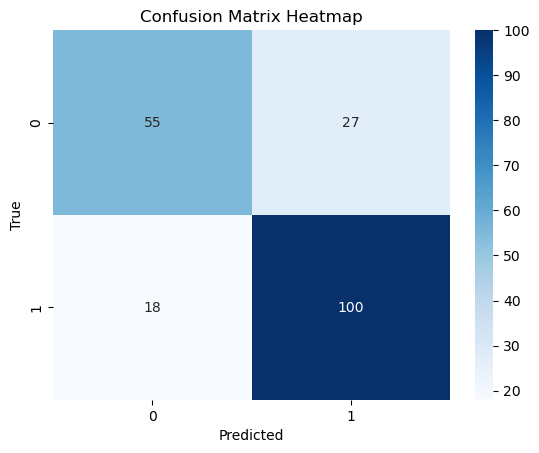

In [7]:
# Logistic regression with scikit-learn
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler

# Generate synthetic binary classification data
np.random.seed(42)
n_samples = 1000
n_features = 2
X = np.random.randn(n_samples, n_features)

# True coefficients
b0, b1, b2 = 0.5, 1.0, -1.5
log_odds = b0 + b1 * X[:, 0] + b2 * X[:, 1]
prob = 1 / (1 + np.exp(-log_odds))
y = np.random.binomial(1, prob)
data = pd.DataFrame(X, columns=['X1', 'X2'])
data['y'] = y

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(data[['X1', 'X2']], data['y'], test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Fit without regularization
model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
print("Coefficients:", model.coef_, "Intercept:", model.intercept_)

# heatmap of confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
# Generate synthetic multiclass classification data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_classes=3, n_informative=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Fit multiclass logistic regression model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=100)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob, multi_class='ovr'))
print(classification_report(y_test, y_pred))


Accuracy: 0.625
AUC: 0.7988563732999908
              precision    recall  f1-score   support

           0       0.67      0.62      0.65        66
           1       0.58      0.65      0.61        63
           2       0.63      0.61      0.62        71

    accuracy                           0.62       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.62      0.63       200



c:\Users\regin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
